In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# EDA

In [ ]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test_without_labels.csv")
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        7000 non-null   int64  
 1   CustomerId       7000 non-null   int64  
 2   Surname          7000 non-null   str    
 3   CreditScore      7000 non-null   int64  
 4   Geography        7000 non-null   str    
 5   Gender           7000 non-null   str    
 6   Age              7000 non-null   int64  
 7   Tenure           7000 non-null   int64  
 8   Balance          7000 non-null   float64
 9   NumOfProducts    7000 non-null   int64  
 10  HasCrCard        7000 non-null   int64  
 11  IsActiveMember   7000 non-null   int64  
 12  EstimatedSalary  7000 non-null   float64
 13  Exited           7000 non-null   int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 765.8 KB


In [3]:
df_train.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [4]:
df_train.shape

(7000, 14)

In [5]:
df_train.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,3888,15769110,Stehle,653,France,Female,46,5,0.00,2,1,0,49707.85,0
1,6618,15700826,Ko,678,Germany,Female,54,1,123699.28,2,0,1,105221.76,0
2,6622,15710365,Thomson,646,France,Male,50,0,104129.24,2,1,0,181794.86,1
3,6627,15619932,Lombardi,847,France,Male,66,7,123760.68,1,0,1,53157.16,0
4,8353,15641413,Crawford,587,Germany,Female,49,7,155393.98,2,1,0,13308.20,1


In [6]:
dcols = ['RowNumber','CustomerId','Surname']
df_train = df_train.drop(dcols,axis=1)
df_test = df_test.drop(dcols,axis=1)
df_train.shape

(7000, 11)

In [7]:
df_test.shape

(3000, 10)

In [8]:
df_train.describe(include='all')

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,7000.000000,7000,7000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
unique,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,3731,3855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,656.569143,NaN,NaN,38.354714,4.899714,63472.755893,1.593286,0.708286,0.604429,99713.609907,0.181000
std,95.271157,NaN,NaN,10.251685,2.883349,62086.696345,0.567376,0.454584,0.489008,57642.616664,0.385046
min,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,595.000000,NaN,NaN,31.000000,2.000000,0.000000,1.000000,0.000000,0.000000,49870.507500,0.000000
50%,657.000000,NaN,NaN,37.000000,5.000000,75439.280000,2.000000,1.000000,1.000000,99796.845000,0.000000
75%,722.000000,NaN,NaN,43.000000,7.000000,119273.295000,2.000000,1.000000,1.000000,149400.107500,0.000000


In [9]:
df_train.isna().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
df_test.isna().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64

In [11]:
df_train.duplicated().sum()

np.int64(0)

In [12]:
df_test.duplicated().sum()

np.int64(0)

In [13]:
df_train.corr(numeric_only=True)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,-0.002101,0.009243,0.036283,-0.011627,0.001841,-0.003754,0.007708,-0.108203
Age,-0.002101,1.000000,-0.032588,0.048532,-0.069273,-0.014676,-0.028324,-0.002119,0.375804
Tenure,0.009243,-0.032588,1.000000,-0.043877,0.025545,0.022479,-0.021451,0.004275,-0.063052
Balance,0.036283,0.048532,-0.043877,1.000000,-0.320333,-0.012634,0.137243,0.015677,0.237334
NumOfProducts,-0.011627,-0.069273,0.025545,-0.320333,1.000000,-0.000283,-0.084038,0.009601,-0.190115
HasCrCard,0.001841,-0.014676,0.022479,-0.012634,-0.000283,1.000000,-0.012698,-0.018455,0.006205
IsActiveMember,-0.003754,-0.028324,-0.021451,0.137243,-0.084038,-0.012698,1.000000,-0.002937,-0.404305
EstimatedSalary,0.007708,-0.002119,0.004275,0.015677,0.009601,-0.018455,-0.002937,1.000000,0.018328
Exited,-0.108203,0.375804,-0.063052,0.237334,-0.190115,0.006205,-0.404305,0.018328,1.000000


In [14]:
df_train.nunique()

CreditScore         456
Geography             3
Gender                2
Age                  69
Tenure               11
Balance            3825
NumOfProducts         4
HasCrCard             2
IsActiveMember        2
EstimatedSalary    7000
Exited                2
dtype: int64

In [15]:
df_train['Geography'].unique()
df_train['Geography'].value_counts()

Geography
France     3731
Spain      1871
Germany    1398
Name: count, dtype: int64

In [16]:
df_train['Exited'].value_counts()

Exited
0    5733
1    1267
Name: count, dtype: int64

In [17]:
df_train.groupby(df_train['Balance']==0)['Exited'].mean()

Balance
False    0.260460
True     0.085327
Name: Exited, dtype: float64

In [18]:
df_train.groupby('Geography')['Exited'].mean()

Geography
France     0.119807
Germany    0.427754
Spain      0.118653
Name: Exited, dtype: float64

In [19]:
df_train.groupby('Gender')['Exited'].mean()

Gender
Female    0.220986
Male      0.148379
Name: Exited, dtype: float64

In [20]:
df_train.groupby(df_train['EstimatedSalary']<50)['Exited'].mean()

EstimatedSalary
False    0.180883
True     1.000000
Name: Exited, dtype: float64

In [21]:
df_train.groupby(df_train['EstimatedSalary']<50)['Exited'].count()

EstimatedSalary
False    6999
True        1
Name: Exited, dtype: int64

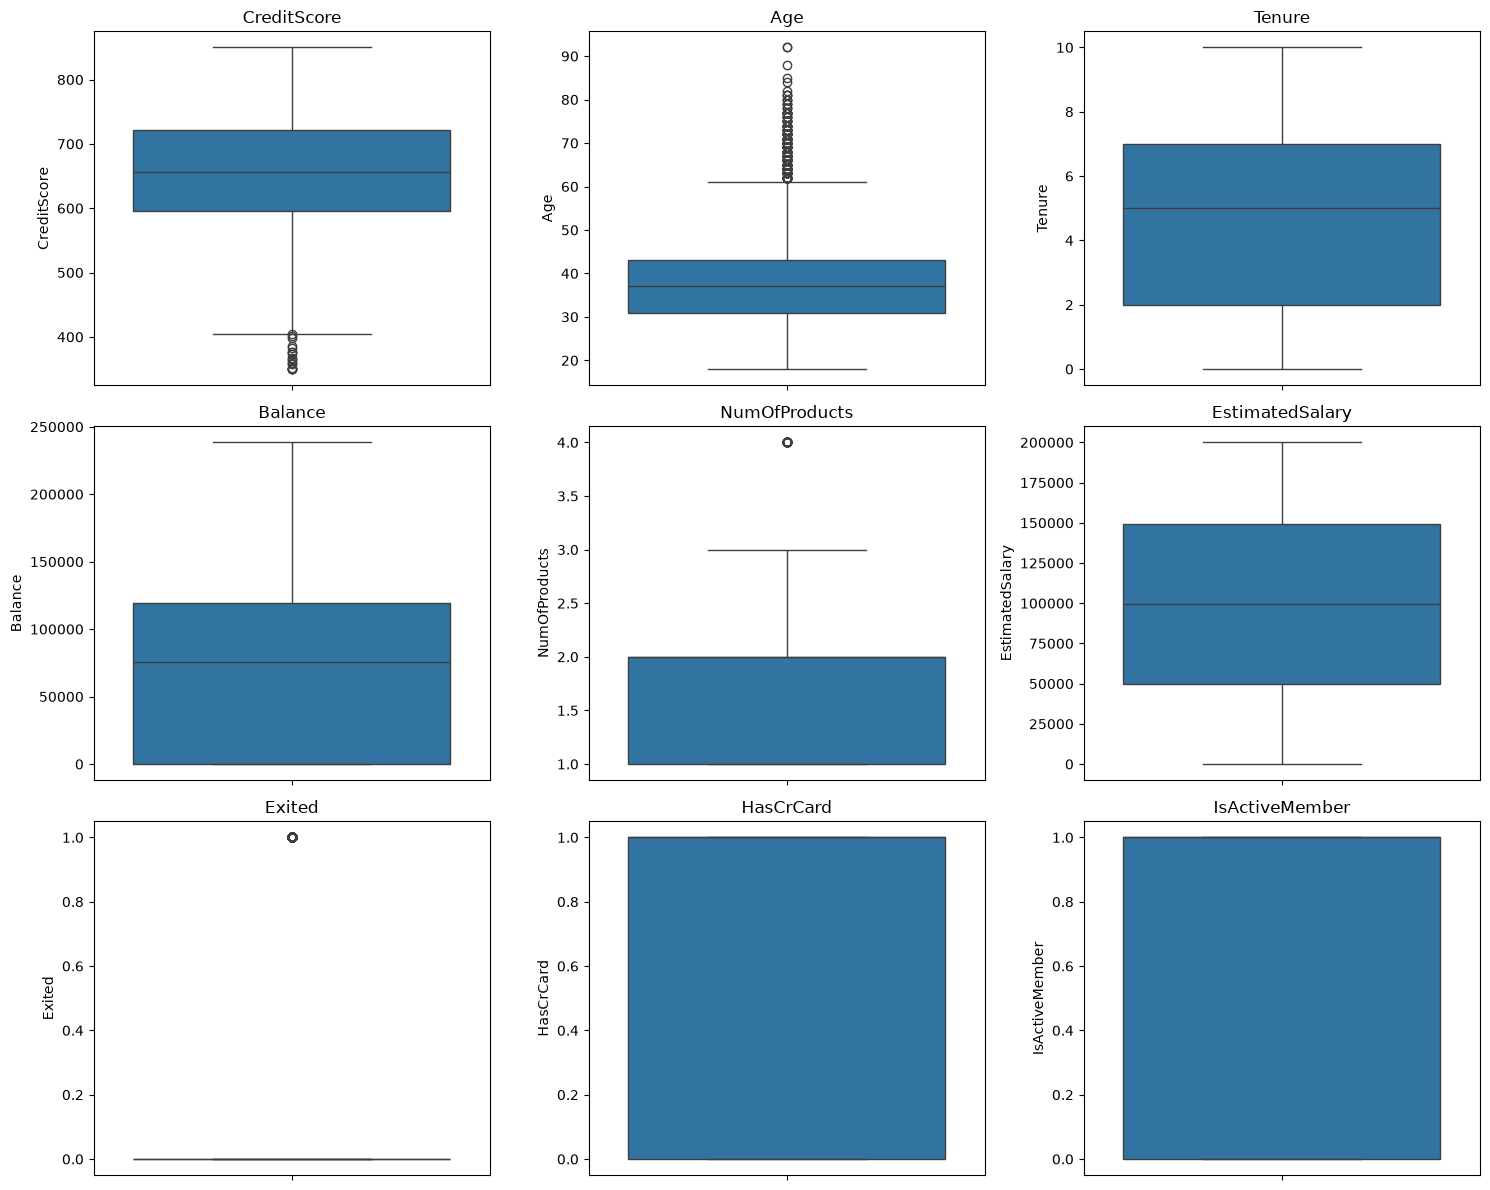

In [26]:
numerical_features = df_train[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary','Exited','HasCrCard','IsActiveMember']]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(y=df_train[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# Feature Engineering 

In [23]:
df_train['IsBalanceZero'] = (df_train['Balance'] == 0).astype(int)
df_test['IsBalanceZero'] = (df_test['Balance'] == 0).astype(int)

In [27]:
df_train[['Balance','IsBalanceZero']].head(10)

,Balance,IsBalanceZero
0,0.00,1
1,123699.28,0
2,104129.24,0
3,123760.68,0
4,155393.98,0
5,155059.10,0
6,124495.98,0
7,87926.24,0
8,0.00,1
9,0.00,1


In [28]:
ohe = OneHotEncoder(sparse_output=False, drop=None, handle_unknown='ignore')
ohe.fit(df_train[['Geography']])

train_encoded = ohe.transform(df_train[['Geography']])
test_encoded = ohe.transform(df_test[['Geography']])

encoded_cols = ohe.get_feature_names_out(['Geography'])

df_train[encoded_cols] = train_encoded
df_test[encoded_cols] = test_encoded

df_train = df_train.drop('Geography', axis=1)
df_test = df_test.drop('Geography', axis=1)

In [29]:
df_test.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'IsBalanceZero',
       'Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype='str')

In [30]:
df_train.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'IsBalanceZero', 'Geography_France', 'Geography_Germany',
       'Geography_Spain'],
      dtype='str')

In [31]:
gender_map = {'Male': 1, 'Female': 0}

df_train['Gender'] = df_train['Gender'].map(gender_map)
df_test['Gender'] = df_test['Gender'].map(gender_map)

In [33]:
df_train['Gender'].unique()
df_train.head()
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        7000 non-null   int64  
 1   Gender             7000 non-null   int64  
 2   Age                7000 non-null   int64  
 3   Tenure             7000 non-null   int64  
 4   Balance            7000 non-null   float64
 5   NumOfProducts      7000 non-null   int64  
 6   HasCrCard          7000 non-null   int64  
 7   IsActiveMember     7000 non-null   int64  
 8   EstimatedSalary    7000 non-null   float64
 9   Exited             7000 non-null   int64  
 10  IsBalanceZero      7000 non-null   int64  
 11  Geography_France   7000 non-null   float64
 12  Geography_Germany  7000 non-null   float64
 13  Geography_Spain    7000 non-null   float64
dtypes: float64(5), int64(9)
memory usage: 765.8 KB


In [35]:
cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
scaler = StandardScaler()
scaler.fit(df_train[cols_to_scale])

df_train[cols_to_scale] = scaler.transform(df_train[cols_to_scale])
df_test[cols_to_scale] = scaler.transform(df_test[cols_to_scale])

In [36]:
df_train[cols_to_scale].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03
mean,-2.273737e-16,-1.400784e-16,9.744586e-17,-6.496391e-17,1.136868e-16,1.750980e-16
std,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-3.218089e+00,-1.985641e+00,-1.699435e+00,-1.022398e+00,-1.045741e+00,-1.729782e+00
25%,-6.462978e-01,-7.174664e-01,-1.005748e+00,-1.022398e+00,-1.045741e+00,-8.647536e-01
50%,4.522753e-03,-1.321550e-01,3.478347e-02,1.927527e-01,7.168854e-01,1.444088e-03
75%,6.868346e-01,4.531565e-01,7.284709e-01,8.988161e-01,7.168854e-01,8.620366e-01
max,2.030464e+00,5.233200e+00,1.769002e+00,2.817468e+00,4.242138e+00,1.739790e+00


In [37]:
cols = [c for c in df_train.columns if c != 'Exited'] + ['Exited']
df_train = df_train[cols]

In [38]:
df_train.to_csv('train_preprocessed.csv', index=False)
df_test.to_csv('test_preprocessed.csv', index=False)